In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import os
from spatialdata.models import Image2DModel
import numpy as np
import tifffile
import spatialdata as sd
import pandas as pd
from skimage.measure import regionprops_table
import spatialdata_plot
import spatialdata_io
import matplotlib.pyplot as plt
import seaborn as sns
import zarr
from copy import copy
import matplotlib.colors as mcolors
import dask.array as da
import skimage.measure
import xmltodict
from spatialdata import SpatialData
import spatialdata as sd
import cv2

%config InlineBackend.figure_format = 'retina'


In [ ]:
def ismember(a, b):
    bind = {}
    for i, elt in enumerate(b):
        if elt not in bind:
            bind[elt] = i
    result = np.array([bind.get(itm, None) for itm in a])  # None can be replaced by any other "not in b" value
    result = [result, np.array([not x is None for x in result])]
    return result

def grep(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[valid_entries]
    
def grep_exclude(pattern, my_list):
    valid_entries = np.array([pattern in x for x in my_list])
    return np.array(my_list)[np.logical_not(valid_entries)]

def imnormalize(img, quantile_low = 0.1, quantile_high = 0.99):
    img = img - np.quantile(np.ravel(img), quantile_low)
    img = img / np.quantile(np.ravel(img), quantile_high)
    img = np.clip(img, 0, 1)
    return(img)

def im2rgb(IM, color, quantile_high = 0.99, quantile_low = 0.1):
    norm = imnormalize(IM, quantile_low = quantile_low, quantile_high = quantile_high)
    RGB = np.zeros(list(norm.shape) + [3])
    for i in range(len(color)):
        RGB[...,i] = color[i] * norm
    return(RGB)

def imblend(G, R = [], B = []):
    G = im2rgb(G, [0,1,0])
    if len(R) > 0:
        R = im2rgb(R, [1,0,0])
    else:
        R = np.zeros(R.shape)
    if len(B) > 0:
        B = im2rgb(B, [0,0,1])
    else:
        B = np.zeros(B.shape)
    IM = R + G + B
    return(IM)

def imoverlay(IM, mask, color=[1,1,1], px=0):
    from skimage.segmentation import find_boundaries
    if len(IM.shape) == 2:
        overlay_data = im2rgb(IM, [1,1,1])
    else:
        overlay_data = IM.copy()
    boundary = find_boundaries(mask, connectivity=1, mode='inner')
    boundary_mask = np.zeros(overlay_data.shape[:2])
    boundary_mask[boundary > 0] = 1
    if px > 0:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(px,px))
        boundary_mask = cv2.dilate(boundary_mask,kernel,iterations = 1)
    for i in range(len(color)):
        overlay_data[boundary_mask > 0,i] = color[i]
    return(overlay_data)


In [ ]:
SLIDE_ID = "JR-sp-15-011"
sdata_path = os.path.join("../sdata", SLIDE_ID)
sdata = sd.read_zarr(sdata_path)

version mismatch: detected: RasterFormatV02, requested: FormatV04
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/data1/lowes/reyesj3/miniconda3/envs/sopa/lib/python3.12/site-

In [ ]:
sdata.is_self_contained()

True

In [ ]:
channels = np.array(sd.models.get_channel_names(sdata.images["COMET"])).tolist()
def get_image(sdata, key, scale, channel):
    idx = channels.index(channel)
    return sdata.images[key][scale].image[idx].values

scale = "scale2"
img_nucleus = get_image(sdata, "COMET", scale, "DAPI")
img_cytoplasm = get_image(sdata, "COMET", scale, "E-cadherin")

In [ ]:
img_nucleus_norm = imnormalize(img_nucleus)
img_cytoplasm_norm = imnormalize(img_cytoplasm)
img_cellpose = np.array([img_nucleus_norm,img_cytoplasm_norm,])
img_cellpose_nucleus = np.array([img_nucleus_norm])

In [ ]:
import cv2
nucleus_thumb = cv2.resize(img_nucleus_norm, None, fx = 0.1, fy = 0.1, interpolation=cv2.INTER_LINEAR)
cyto_thumb = cv2.resize(img_cytoplasm_norm, None, fx = 0.1, fy = 0.1, interpolation=cv2.INTER_LINEAR)

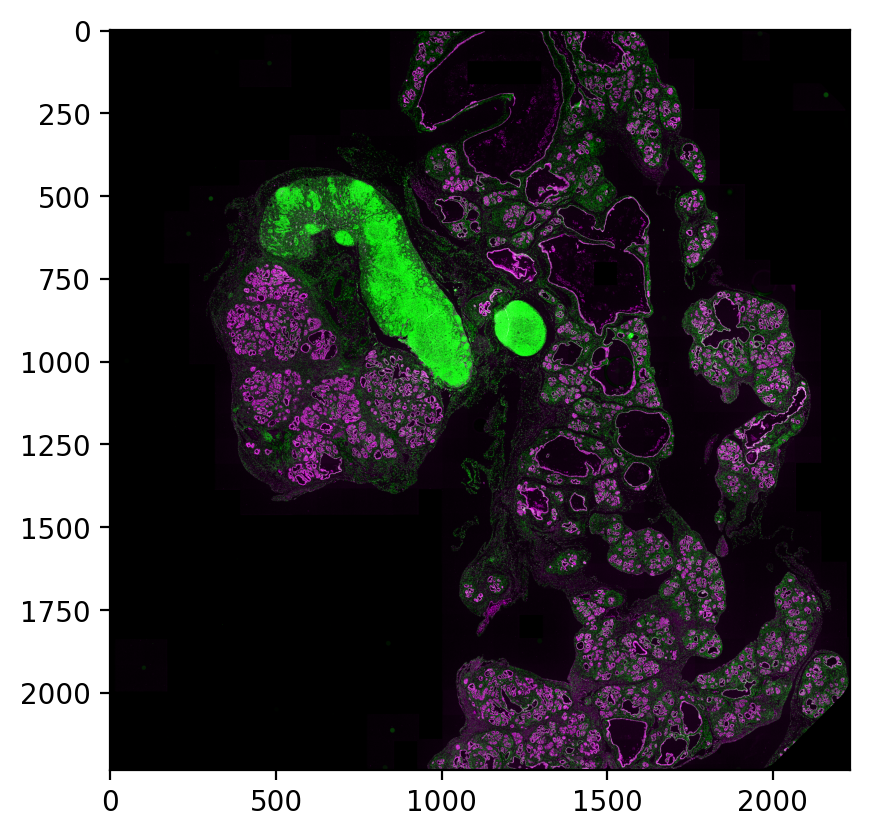

In [ ]:
plt.imshow(imblend(nucleus_thumb, cyto_thumb, cyto_thumb))

#### Cytoplasmic masks

In [ ]:
os.makedirs("../cellpose_masks_cyto", exist_ok= True)
mask_path = os.path.join("../cellpose_masks_cyto", SLIDE_ID + "masks.npz")
if os.path.exists(mask_path):
    print("Reading existing masks")
    masks_full = np.load(mask_path)['arr_0']
else:
    print("Running cellpose")

    import cellpose.models

    # model parameters
    flow_threshold = 0.4
    cellprob_threshold = 0.0
    tile_norm_blocksize = 0
    
    # run cellpose
    model = cellpose.models.CellposeModel(gpu=True)
    masks, flows, styles = model.eval(
        img_cellpose,
        batch_size=64,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize}
    )
    
    shape_full = sdata.images["COMET"]["scale0"].image.shape[1:]
    
    # scale to full shape, do not interpolate
    import skimage.transform
    masks_full = skimage.transform.resize(masks, shape_full, order=0, preserve_range=True)
    
    assert masks_full.shape == shape_full, f"Mask full shape {masks_full.shape} not equal to full shape {shape_full}"
    
    # add to spatialdata
    np.savez_compressed(mask_path, masks_full)

print("Adding masks to sdata")
sdata.images["cellpose_masks"] = sd.models.Image2DModel.parse(masks_full[np.newaxis, ...], dims=["c", "y", "x"])


Running cellpose


more than 65535 masks in image, masks returned as np.uint32


Adding masks to sdata


#### Nucleus masks

In [ ]:
os.makedirs("../cellpose_masks_nucleus", exist_ok= True)
mask_path = os.path.join("../cellpose_masks_nucleus", SLIDE_ID + "masks.npz")
if os.path.exists(mask_path):
    print("Reading existing masks")
    masks_full_nucleus = np.load(mask_path)['arr_0']
else:
    print("Running cellpose")

    import cellpose.models

    # model parameters
    flow_threshold = 0.4
    cellprob_threshold = 0.0
    tile_norm_blocksize = 0
    
    # run cellpose
    model = cellpose.models.CellposeModel(gpu=True)
    masks, flows, styles = model.eval(
        img_cellpose_nucleus,
        batch_size=64,
        flow_threshold=flow_threshold,
        cellprob_threshold=cellprob_threshold,
        normalize={"tile_norm_blocksize": tile_norm_blocksize}
    )
    
    shape_full = sdata.images["COMET"]["scale0"].image.shape[1:]
    
    # scale to full shape, do not interpolate
    import skimage.transform
    masks_full_nucleus = skimage.transform.resize(masks, shape_full, order=0, preserve_range=True)
    
    assert masks_full_nucleus.shape == shape_full, f"Mask full shape {masks_full_nucleus.shape} not equal to full shape {shape_full}"
    
    # add to spatialdata
    np.savez_compressed(mask_path, masks_full_nucleus)

print("Adding masks to sdata")
sdata.images["cellpose_masks_nucleus"] = sd.models.Image2DModel.parse(masks_full_nucleus[np.newaxis, ...], dims=["c", "y", "x"])


Running cellpose


#### Verify output

In [ ]:
mask_thumb = cv2.resize(masks_full_nucleus.astype(np.float32), None, fx = 0.05, fy = 0.05, interpolation=cv2.INTER_LINEAR)
mask_nucleus_thumb = cv2.resize(masks_full_nucleus.astype(np.float32), None, fx = 0.05, fy = 0.05, interpolation=cv2.INTER_LINEAR)

In [ ]:
mask_cyto_reference = cv2.resize(masks_full.astype(np.float32), None, fx = 0.5, fy = 0.5, interpolation=cv2.INTER_LINEAR)
mask_nucleus_reference = cv2.resize(masks_full_nucleus.astype(np.float32), None, fx = 0.5, fy = 0.5, interpolation=cv2.INTER_LINEAR)

In [ ]:
bounds = [[11500,12500], [5000,6000]]
bounds = [[15500,16500], [15000,16000]]
zoom_nucleus = img_nucleus_norm[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
zoom_cyto = img_cytoplasm_norm[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
zoom_mask = mask_cyto_reference[bounds[0][0]: bounds[0][1], bounds[1][0]: bounds[1][1]]
plt.imshow(imoverlay(imblend(zoom_nucleus, zoom_cyto, zoom_cyto), zoom_mask, [1,1,1], px=2))

#### Consolidate nucleus and cytoplasmic masks

In [ ]:
unique_values_full = np.unique(np.ravel(masks_full))
print("Total cells in cytoplasmic mask: " + str(len(unique_values_full)))

mask_cyto_mask is the nucleus-masked cytoplasmic segmentation

In [ ]:
mask_cyto_mask = np.multiply(masks_full, (masks_full_nucleus > 0).astype(np.uint8))
unique_values = np.unique(np.ravel(mask_cyto_mask))
print("Total cells in after intersecting with nuclear mask: " + str(len(unique_values)))

mask_cyto_final is the cytoplasmic segmentation mask

In [ ]:
mask_cyto_final = np.multiply(masks_full, np.isin(masks_full, unique_values).astype(np.uint8))
unique_values_final = np.unique(np.ravel(mask_cyto_final))
print("Kept: " + str(len(unique_values_final) / len(unique_values_full)))

In [ ]:
os.makedirs("../cellpose_masks_consolidated", exist_ok = True)
mask_path = os.path.join("../cellpose_masks_consolidated", SLIDE_ID + "_masks_nucleus_consolidated.npz")
np.savez_compressed(mask_path, mask_cyto_mask)
mask_path = os.path.join("../cellpose_masks_consolidated", SLIDE_ID + "_masks_cyto_consolidated.npz")
np.savez_compressed(mask_path, mask_cyto_final)